# Metrics

In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)


df_transformers = pd.read_csv(
    "./results/two-stage/topic-classification/transformers-predictions.csv"
)
df_classics = pd.read_csv(
    "./results/two-stage/topic-classification/classics-predictions.csv"
)

df_all = pd.concat([df_transformers, df_classics], ignore_index=True)

models = df_all["model"].unique()


def compute_metrics(y_true, y_pred):
    accuracy = np.round(accuracy_score(y_true, y_pred), 3)
    precision = np.round(
        precision_score(y_true, y_pred, average="macro", zero_division=0), 3
    )
    recall = np.round(recall_score(y_true, y_pred, average="macro", zero_division=0), 3)
    f1_macro = np.round(f1_score(y_true, y_pred, average="macro", zero_division=0), 3)
    f1_weighted = np.round(
        f1_score(y_true, y_pred, average="weighted", zero_division=0), 3
    )
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }


def make_summary(df, model_name):
    y_true = df["y_true"]
    y_pred = df["y_pred_real"]
    metrics = compute_metrics(y_true, y_pred)
    return {"model": model_name, **metrics}


results = []
for model in models:
    results.append(make_summary(df_all[df_all["model"] == model], model))

# metrics summary
df_results = pd.DataFrame(
    results,
    columns=[
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1_macro",
        "f1_weighted",
    ],
)
df_results = df_results.sort_values(by="f1_macro", ascending=False).reset_index(
    drop=True
)
df_results.to_csv(
    "./results/two-stage/topic-classification/summary-metrics.csv", index=False
)


print(df_results)

        model  accuracy  precision  recall  f1_macro  f1_weighted
0        bert     0.679      0.643   0.634     0.621        0.673
1         svc     0.667      0.598   0.626     0.596        0.662
2          lr     0.658      0.601   0.603     0.592        0.656
3  distilbert     0.663      0.597   0.611     0.590        0.659
4          nb     0.648      0.613   0.568     0.572        0.640
5          rf     0.608      0.572   0.550     0.542        0.602


# Confusion Matrix

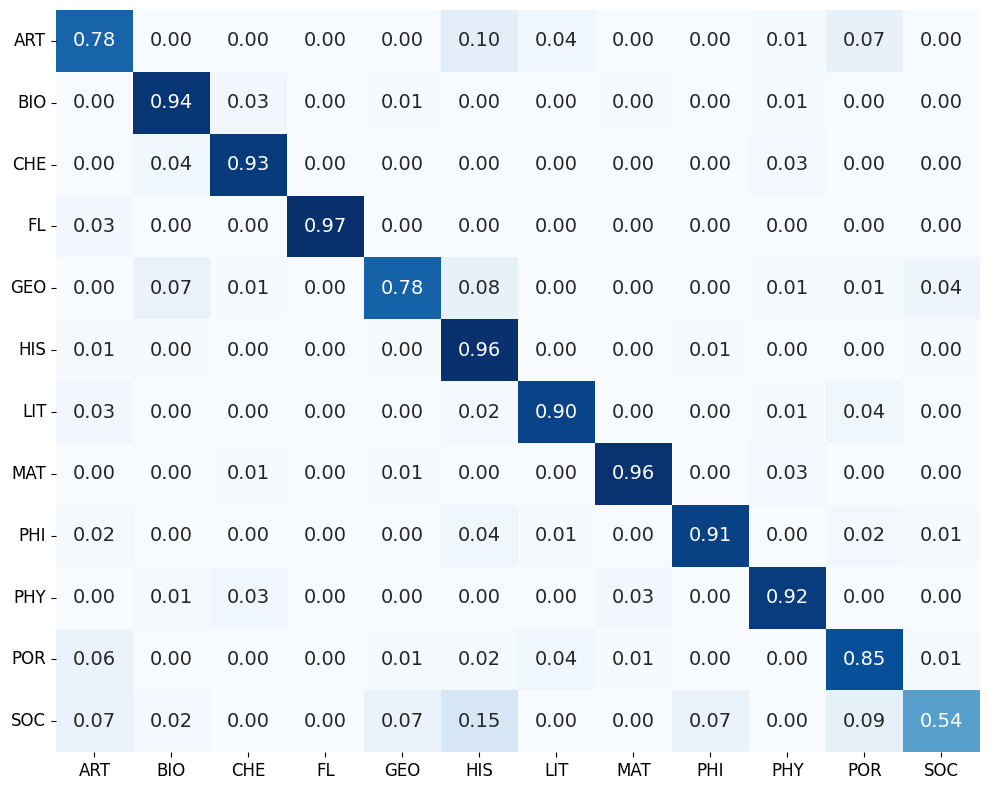

In [3]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("./results/two-stage/subject-classification/bert-predictions.csv")

# O seu dicionário de mapeamento (De -> Para)
novos_nomes = {
    "artes": "ART",
    "biologia": "BIO",
    "filosofia": "PHI",
    "fisica": "PHY",
    "geografia": "GEO",
    "historia": "HIS",
    "idiomas": "FL",
    "literatura": "LIT",
    "matematica": "MAT",
    "portugues": "POR",
    "quimica": "CHE",
    "sociologia": "SOC",
}

df["y_true"] = df["y_true"].map(novos_nomes)
df["y_pred"] = df["y_pred"].map(novos_nomes)

# Extrai os valores reais e preditos
y_true = df["y_true"]
y_pred = df["y_pred"]

# Gera a matriz de confusão
mat_norm = confusion_matrix(
    y_true, y_pred, labels=sorted(df["y_true"].unique()), normalize="true"
)

# Transforma em DataFrame para visualização
materias = sorted(df["y_true"].unique())
df_conf = pd.DataFrame(mat_norm, index=materias, columns=materias)

# Visualiza a matriz de confusão
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    df_conf, annot=True, fmt=".2f", cmap="Blues", cbar=False, annot_kws={"size": 14}
)

# Aumentando a fonte dos eixos X e Y
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
ax.set_yticklabels(
    ax.get_yticklabels(), fontsize=12, rotation=0
)  # rotation=0 deixa o texto na horizontal
# plt.title("Matriz de Confusão - BERT")
# plt.xlabel("Predição do BERT")
# plt.ylabel("Matéria Real")
plt.tight_layout()
plt.show()

# df_conf.round(3)

# F1 comparison subject

In [5]:
import pandas as pd
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy as np

df_classics = pd.read_csv("./results/two-stage/topic-classification/classics-predictions.csv")
df_transformers = pd.read_csv("./results/two-stage/topic-classification/transformers-predictions.csv")
df = pd.concat([df_classics, df_transformers], ignore_index=True)

modelos = ["bert", "distilbert", "svc", "lr", "nb", "rf"]

# Função que calcula F1 macro por matéria e modelo
def f1_macro_por_materia(modelo, materia, df):
    df_modelo = df[df["model"] == modelo]
    df_materia = df_modelo[df_modelo["subject_true"] == materia]
    return f1_score(
        df_materia["y_true"], df_materia["y_pred_gold"], average="macro", zero_division=0
    )


# Monta uma tabela com os valores de F1
f1_data = []
for materia in df["subject_true"].unique():
    row = {"subject": materia}
    for modelo in modelos:
        row[modelo] = f1_macro_por_materia(modelo, materia, df)
    f1_data.append(row)

f1_data_df = pd.DataFrame(f1_data)
f1_data_df = f1_data_df.groupby("subject").mean().round(3)
df_f1 = pd.DataFrame(f1_data_df)
df_f1["subject"] = df_f1.index
df_f1 = df_f1.reset_index(drop=True)
df_f1.sort_values(by="bert", ascending=False, inplace=True)

df_f1

,bert,distilbert,svc,lr,nb,rf,subject
6,1.000,1.000,1.000,1.000,1.000,1.000,idiomas
11,0.828,0.672,0.741,0.702,0.728,0.762,sociologia
7,0.788,0.643,0.779,0.785,0.759,0.723,literatura
3,0.749,0.686,0.700,0.696,0.688,0.693,fisica
5,0.740,0.707,0.722,0.722,0.699,0.666,historia
10,0.728,0.709,0.729,0.693,0.718,0.649,quimica
2,0.719,0.727,0.658,0.644,0.577,0.531,filosofia
4,0.658,0.637,0.620,0.624,0.531,0.515,geografia
9,0.636,0.547,0.574,0.562,0.445,0.414,portugues
8,0.619,0.662,0.638,0.608,0.608,0.595,matematica


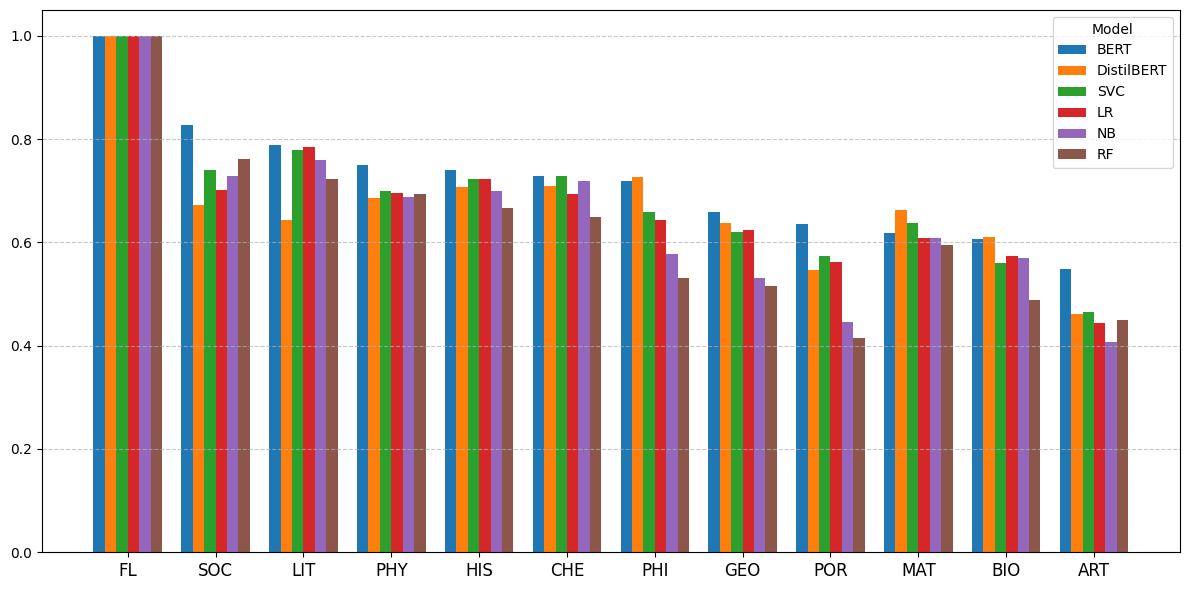

In [6]:
# O seu dicionário de mapeamento (De -> Para)
novos_nomes = {
    "artes": "ART",
    "biologia": "BIO",
    "filosofia": "PHI",
    "fisica": "PHY",
    "geografia": "GEO",
    "historia": "HIS",
    "idiomas": "FL",
    "literatura": "LIT",
    "matematica": "MAT",
    "portugues": "POR",
    "quimica": "CHE",
    "sociologia": "SOC",
}

df_f1["subject"] = df_f1["subject"].map(novos_nomes)

modelo2name = {
    "bert": "BERT",
    "distilbert": "DistilBERT",
    "svc": "SVC",
    "lr": "LR",
    "rf": "RF",
    "nb": "NB",
}

df_f1.sort_values(by="bert", ascending=False, inplace=True)

# ---------- GRÁFICO DE BARRAS AGRUPADAS ----------
x = np.arange(len(df_f1["subject"]))
largura = 0.13  # largura de cada barra

fig, ax = plt.subplots(figsize=(12, 6))

for i, modelo in enumerate(modelos):
    ax.bar(x + i * largura, df_f1[modelo], width=largura, label=modelo2name[modelo])

# ax.set_xlabel("Matéria", fontsize=12, fontweight='bold')
# ax.set_ylabel("F1-Macro", fontsize=12, fontweight='bold')
# ax.set_title("Comparação de F1 Score por Matéria e Modelo", fontsize=14)
ax.set_xticks(x + largura * (len(modelos) - 1) / 2)
ax.set_xticklabels(df_f1["subject"], fontsize=12)
ax.legend(title="Model")
ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()